# Practical Homework P4: random-200 KB [Joelle Dizon]

The Team:
* Joelle Dizon - jkd227@lehigh.edu
* Rachel McIntosh - rem526@lehigh.edu
* Zoe Ford - zmf227@lehigh.edu

### Step #1: Importing necessary modules.
The block below imports a necessary module and checks if you are in the right directory. If you do not see a list of python files when you run the block, please make sure you have uploaded the zip file and unzipped it.

In [24]:
import matplotlib.pyplot as plt

%pwd
%ls




 all_facts.txt                            nnreasoner.py
 atomgenerator.py                         nnunifier.py
 autoencoder.py                           potter_model.pt
 basictypes.py                            potter.txt
 chainbased.py                            __pycache__/
'CSE 327 P4 200-7.ipynb'                  reasoner.py
'CSE 327 P4 200-8-Copy1.ipynb'            rKB_model.pth
'CSE 327 P4.ipynb'                        size200/
 embedmodel.py                            std-46-110-3-50.csv
 evaluate.py                              termwalk.py
 gameofthrones.txt                        test_queries.txt
 gen_queries.py                           training_and_validation_loss.png
 guided_loss-unification46-110-3-50.png   training_loss-10-100-4-50.png
 helpers/                                 training_loss-10-97-5-50.png
 kbencoder.py                             training_loss-45-106-2-50.png
 kbparser.py                              training_loss-46-110-3-50.png
 knowledgebase.py        

### Step #2: Create a random KB

**Creates the files:**

* randomKB.txt - A random KB generated using 10 predicates and 100 constants.
* vocab.pkl - Indexes the full set of predicates, constants and variables used by the knowledge base.

In [2]:
%cd size200 # enter correct directory

!python ../../kbencoder.py --generate_kb --num_rules 200 --new_vocab --save_vocab
!head randomKB.txt

/data/users/jupyter-jkd227/cse327-p4-files/size200
Classes: 10000000.0
Max arity: 3
KB generated (200)
p8(a1).
p5(a19).
p1(a35, a28, a13).
p2(a0).
p5(a11).
p4(a15, a0, a27).
p2(a19).
p9(a69).
p6(a49, a64).
p1(a30, a65, a30).


### Step #3: Train the neural net

Train a neural net to convert first-order logic atoms into meaningful numeric vectors. We call these vectors "embeddings," and the learned model the embedding model. The code creates random atoms and then uses a mechanism known as triplet loss to place unifying atoms closer together.

**Creates the files:**

*   rKB_model.pth - Saves the learned weights for the embedding model
*   training_loss-45-106-2-50.png - A plot of the training loss after each epoch. This file's name depends on the vocabulary of your KB: the four numbers are number of predicates, number of constants, max arity of the predicates, and the embedding size used. If you changed the KB, you'll need to look up the name in your drive and update the code block that displays this file.


In [26]:
%cd size200
!python ../kbencoder.py --kb_path randomKB.txt --train_unification_model

# for modified embed size:
# !python ../kbencoder.py --kb_path randomKB.txt --train_unification_model --embed_size 25

[Errno 2] No such file or directory: 'size200'
/data/users/jupyter-jkd227/cse327-p4-files/size200
Using cuda device
Uni model embed size: 25
 [████████████████████] 3500/3500 Anchors generated                                                 
 [████████████████████] 70000/70000 Triplets generated                                              
 [██████--------------] 24298/70000 Triplet encodings                                               

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



 [██████████████████--] 66358/70000 Triplet encodings                                               

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



Early stopping triggered-------------] 23.0% Epoch | [Epoch 116/500, Training Loss: 0.2447, Validation Loss: 0.4518]
Saved model.
Saved plot.
unification model generated


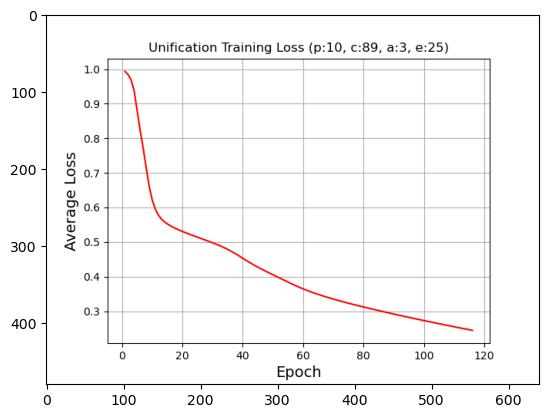

In [27]:
# Reading the plot of the training loss
img = plt.imread('training_loss-10-89-3-25.png')
plt. imshow(img)

### Step #4: Generate set of train & test queries

Generate a set of train and test queries from your knowledge base. This will also generate the deductive closure (all facts that can be inferred) of your KB using forward-chaining.

**Produces the files:**

*  all_facts.txt - A list of all facts that can be inferred from the KB. This is used to generate queries that are guaranteed to have an answer.
*  train_queries.txt - A set of training queries where each will have at least one answer.
*  test_queries.txt - A set of test queries where each will have at least one answer.


In [8]:
!python ../kbencoder.py --kb_path randomKB.txt -g

Generating facts list...
Forward chaining depth: 1
New facts: 45
Forward chaining depth: 2
New facts: 13
Forward chaining depth: 3
New facts: 2
Forward chaining depth: 4

Facts list generated
60 total facts. Max depth = 3

Number of queries: 200
100 training queries generated
100 testing queries generated


### Step #5: Create a training set for the scoring model

Create a training set for the scoring model. The examples will consist of goal, rule, score pairs, where a score of 1 means the rule can solve the goal, and 0 means it cannot. It runs the full set of training queries with a randomized backward-chaining process. This step can sometimes take a long time and is not able to take advantage of a GPU (with the gameofthrones KB it took ~45 minutes).

**Creates a file:**
*  mr_train_examples.csv - Contains a line for each goal/rule/score example.

In [9]:
!python ../kbencoder.py --kb_path randomKB.txt -p

running training queries...
Negative facts will be generated
1: [p6(X8, X8)]
min depth: 9                                                                                        
min depth: 8                                                                                        
min depth: 7                                                                                        
Nodes: 5937                                                                                         
Answers: 88                                                                                         

2: [p0(X6, a2, X6)]
min depth: 4                                                                                        
Nodes: 17548                                                                                        
Answers: 512                                                                                        

3: [p3(X1, X0), p4(a38, a95, X0), p0(X0, a2, X0)]
min depth: 1                               

### Step #6: Train the scoring model

Train the scoring model. This step will usually take several minutes, especially if you are not using a GPU (for the gameofthrones KB, it takes about 30 minutes on CPU).

**Creates a file:**
* uni_mr_model.pt - Contains the weights for the learned scoring model

In [32]:
!python ../nnreasoner.py --embed_type unification -s random200_reg_model.pt

# for modified nnreasoner:
# !python ../nnreasoner-mod.py --embed_type unification -s random200_embed_model.pt

States from vocab: vocab
Num predicates: 10
Max arity: 3
Num constants: 89
Num variables: 10

Training unification
Embed size: 25
Reading examples from mr_train_examples.csv
Parsing examples...
Generating embeddings...
Embedding input size: 307
 [███████████████] 5169/5169 Prepping examples                                                      
Loaded data...
Using cuda device
/opt/tljh/user/envs/cse327python311/lib/python3.11/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
0	0.64116 (-)
50	0.35650 (-0.0054)
100	0.33833 (-0.0029)
150	0.32250 (-0.0020)
200	0.30764 (-0.0016)
250	0.29645 (-0.0013)
300	0.27943 (-0.0012)
350	0.26590 (-0.0010)
400	0.25181 (-0.0009)
450	0.24077 (-0.0008)
500	0.23110 (-0.0008)
550	0.22346 (-0.0007)
600	0.21351 (-0.0007)
650	0.20608 (-0.0006)
700	0.20107 (-0.0006

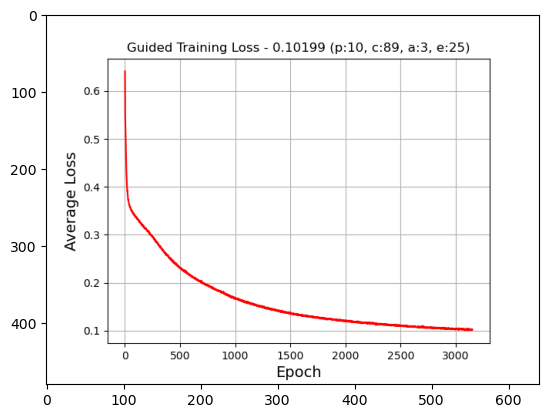

In [34]:
img = plt.imread('guided_loss-unification10-89-3-25.png')
plt.imshow(img)

### Step #7: Evaluate the scoring model -- compare std (-s) with scoring (-u)

Evaluate the scoring model by running evaluate.py. We compare the standard backward-chaining algorithm (-s) with the one that uses our learned scoring model (-u).

The output lists each query, and then provides a line that gives information about query execution. These are: number of nodes explored in the tree, depth of the solution, execution time in seconds, and the speed of exploring the tree (nodes per second).

**The names of the files produced depend on the KB used and the options selected. The code below produces the files:**

* std-45-106-2-50.csv - A CSV file with query results for the standard backward-chaining algorithm
* ming-45-106-2-50.csv - A CSV file with query results for the learned reasoner. ming stands for "min scoring goal" and is the default strategy for deciding how to make use of the scores

If you use a different knowledge base, you will likely get different file names that depend on the features of that KB's vocabulary.

In [43]:
!python ../evaluate.py --kb randomKB.txt -s

!python ../evaluate.py --kb randomKB.txt -u --scoring_model_path random200_reg_model.pt

# for modified embed size:
# !python ../evaluate.py --kb randomKB.txt -u --scoring_model_path random200_embed_model.pt --embed_size 25

using cuda device
STANDARD

Query 1: [p7(X2)]
2 :: 1 - 00:00:00 (6857 nps)                                                                        

Query 2: [p3(X0, a15), p4(X0, a1, a10), p3(a48, X0), p1(a26, X0, X1), p1(a80, a52, X1)]
8 :: 7 - 00:00:00 (5700 nps)                                                                        

Query 3: [p5(X0), p1(a3, X0, X1), p3(X1, a15)]
19 :: 5 - 00:00:00 (5207 nps)                                                                       

Query 4: [p3(X9, a15)]
4 :: 3 - 00:00:00 (8179 nps)                                                                        

Query 5: [p7(X5)]
2 :: 1 - 00:00:00 (10767 nps)                                                                       

Query 6: [p6(a0, X0), p8(X0)]
4 :: 2 - 00:00:00 (8184 nps)                                                                        

Query 7: [p6(a1, X0), p6(a15, X0), p4(a95, a16, X0), p1(a88, X0, a32)]
6 :: 4 - 00:00:00 (3840 nps)                                     

### Step #8: Summary Statistics

The code below shows the first 10 lines of each query result file. A given line has:
* query sequence number
* configuration name
* number of nodes explored
* depth of solution (0 if no solution found)
* did the system find a solution (true/false)
* time in seconds

You can import these files into a spreadsheet in order to create plots or summary statistics.

In [20]:
!head std-10-89-3-50.csv
!head ming-10-89-3-50.csv

query,std reasoner,std nodes explored,std min depth,success,time
1,std,2,1,True,0.00030133700000067876
2,std,8,7,True,0.0013961970000000434
3,std,19,5,True,0.003586340000000021
4,std,4,3,True,0.00047698000000018226
5,std,2,1,True,0.00017878500000012565
6,std,4,2,True,0.0004766390000003895
7,std,6,4,True,0.0015244980000002073
8,std,4,3,True,0.000433995000000742
9,std,6,4,True,0.0010729870000005803
query,ming reasoner,ming nodes explored,ming min depth,success,time
1,ming,2,1,True,0.4422921449999997
2,ming,8,7,True,0.04314285299999909
3,ming,1635,5,True,0.24861717799999994
4,ming,17,15,True,0.10171624600000051
5,ming,2,1,True,0.012210377000000605
6,ming,3,2,True,0.024232662999999377
7,ming,5,4,True,0.02176636899999984
8,ming,17,15,True,0.033599924999998976
9,ming,7,4,True,0.05463066999999988
